In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
import joblib

# Load all 5 quarters
files = {
    '2019 Q2': 'data/raw/qlfs-2019-q2-worker-v1.0.csv',
    '2020 Q2': 'data/raw/qlfs-2020-q2-worker-v2.1.csv',
    '2021 Q2': 'data/raw/qlfs-2021-q2-worker-v1.csv',
    '2022 Q2': 'data/raw/qlfs-2022-q2-worker-v1.csv',
    '2023 Q2': 'data/raw/qlfs-2023-q2-worker-v1.csv'
}

dfs = {}
for year, file in files.items():
    dfs[year] = pd.read_csv(file, encoding='latin1', low_memory=False)
    print(f"{year}: {dfs[year].shape[0]} rows")

# Find common columns
common_cols = set(dfs['2019 Q2'].columns)
for year, df in dfs.items():
    common_cols = common_cols.intersection(set(df.columns))

# Combine
combined = []
for year, df in dfs.items():
    df_subset = df[list(common_cols)].copy()
    df_subset['survey_year'] = year
    combined.append(df_subset)

df_all = pd.concat(combined, ignore_index=True)

# Filter to youth
youth_all = df_all[df_all['age_grp1'].isin(['15-19', '20-24'])]
print("\nTotal youth records:", len(youth_all))
print("NEET distribution:")
print(youth_all['NEET'].value_counts())

2019 Q2: 67626 rows
2020 Q2: 47103 rows
2021 Q2: 53940 rows
2022 Q2: 57244 rows
2023 Q2: 66628 rows

Total youth records: 48948
NEET distribution:
NEET
No     32936
Yes    16012
Name: count, dtype: int64


In [2]:
# Prepare modelling dataset
youth_model = youth_all[youth_all['NEET'].notna()].copy()

# Better imputation strategy
# Q312EVERWRK - if employed, fill as 'Currently employed', 
# if unemployed/inactive and missing, fill as 'No'
youth_model['Q312EVERWRK'] = youth_model.apply(
    lambda row: 'Currently employed' 
    if row['Status'] in ['Employed'] 
    else ('No' if pd.isna(row['Q312EVERWRK']) 
    else row['Q312EVERWRK']), axis=1
)

# Q319hGRANTS - fill missing as 'Not applicable' for employed
youth_model['Q319hGRANTS'] = youth_model['Q319hGRANTS'].fillna('Not applicable')

# Features
features = ['Q13GENDER', 'Q15POPULATION', 'Province', 
            'Education_Status', 'age_grp1',
            'Q16MARITALSTATUS', 'Q312EVERWRK', 'Q319hGRANTS']

print("Missing values:")
print(youth_model[features].isnull().sum())
print("\nQ312EVERWRK distribution:")
print(youth_model['Q312EVERWRK'].value_counts())

Missing values:
Q13GENDER           0
Q15POPULATION       0
Province            0
Education_Status    0
age_grp1            0
Q16MARITALSTATUS    0
Q312EVERWRK         0
Q319hGRANTS         0
dtype: int64

Q312EVERWRK distribution:
Q312EVERWRK
No                    41632
Currently employed     4343
Yes                    2973
Name: count, dtype: int64


In [3]:
X = youth_model[features].copy()
y = (youth_model['NEET'] == 'Yes').astype(int)

ct = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', sparse_output=False), features)
    ]
)

X_encoded = ct.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

xgb_model = XGBClassifier(
    learning_rate=0.01,
    max_depth=5,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not NEET', 'NEET']))

# Save new model and encoder
joblib.dump(xgb_model, 'models/xgb_neet_model.pkl')
joblib.dump(ct, 'models/neet_encoder.pkl')
print("\nModel and encoder saved successfully!")

Accuracy: 80.63 %

Classification Report:
              precision    recall  f1-score   support

    Not NEET       0.93      0.77      0.84      6587
        NEET       0.65      0.89      0.75      3203

    accuracy                           0.81      9790
   macro avg       0.79      0.83      0.80      9790
weighted avg       0.84      0.81      0.81      9790


Model and encoder saved successfully!


In [4]:
xgb_model = XGBClassifier(
    learning_rate=0.01,
    max_depth=5,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not NEET', 'NEET']))

Accuracy: 76.08 %

Classification Report:
              precision    recall  f1-score   support

    Not NEET       0.75      0.98      0.85      6587
        NEET       0.88      0.31      0.46      3203

    accuracy                           0.76      9790
   macro avg       0.81      0.65      0.65      9790
weighted avg       0.79      0.76      0.72      9790



In [5]:
# Try moderate class weight
xgb_model = XGBClassifier(
    learning_rate=0.01,
    max_depth=5,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    scale_pos_weight=2,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not NEET', 'NEET']))

Accuracy: 80.9 %

Classification Report:
              precision    recall  f1-score   support

    Not NEET       0.93      0.77      0.85      6587
        NEET       0.65      0.88      0.75      3203

    accuracy                           0.81      9790
   macro avg       0.79      0.83      0.80      9790
weighted avg       0.84      0.81      0.81      9790



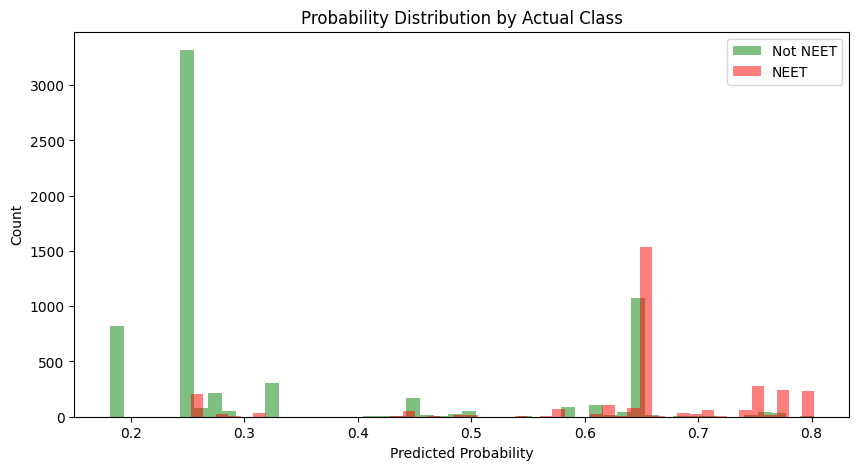

Not NEET mean probability: 0.349
NEET mean probability: 0.641
Overall mean probability: 0.444


In [7]:
# Check probability distribution
y_proba = xgb_model.predict_proba(X_test)[:, 1]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(y_proba[y_test==0], bins=50, alpha=0.5, label='Not NEET', color='green')
plt.hist(y_proba[y_test==1], bins=50, alpha=0.5, label='NEET', color='red')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution by Actual Class')
plt.legend()
plt.show()

print("Not NEET mean probability:", round(y_proba[y_test==0].mean(), 3))
print("NEET mean probability:", round(y_proba[y_test==1].mean(), 3))
print("Overall mean probability:", round(y_proba.mean(), 3))

In [8]:
joblib.dump(xgb_model, 'models/xgb_neet_model.pkl')
joblib.dump(ct, 'models/neet_encoder.pkl')
print("Saved successfully!")

Saved successfully!
